In [ ]:
# Imports
import os
import random
import torch
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
#Reproductibiity
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)
print("Seed set for reproducibility.")

Seed set for reproducibility.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
os.environ["KAGGLE_API_TOKEN"] = "KGAT_be0e6442f3cfdebedc0159d19b1ef38d"

In [ ]:
!pip install kaggle

In [ ]:
import os
os.environ["KAGGLE_API_TOKEN"] = "KGAT_3590e3cb03b6f7dd8ed313cbd31d5e4a"

In [ ]:
!pip install kaggle

In [ ]:
!kaggle competitions list

Traceback (most recent call last):
  File "/usr/local/bin/kaggle", line 4, in <module>
    from kaggle.cli import main
  File "/usr/local/lib/python3.12/dist-packages/kaggle/__init__.py", line 6, in <module>
    api.authenticate()
  File "/usr/local/lib/python3.12/dist-packages/kaggle/api/kaggle_api_extended.py", line 434, in authenticate
    raise IOError('Could not find {}. Make sure it\'s located in'
OSError: Could not find kaggle.json. Make sure it's located in /root/.config/kaggle. Or use the environment method. See setup instructions at https://github.com/Kaggle/kaggle-api/


In [ ]:
from google.colab import files
files.upload()

{}

import os

os.makedirs('/root/.config/kaggle', exist_ok=True)
os.rename('kaggle.json', '/root/.config/kaggle/kaggle.json')
os.chmod('/root/.config/kaggle/kaggle.json', 600)

In [ ]:
!pip install kaggle

In [ ]:
!kaggle competitions list

Traceback (most recent call last):
  File "/usr/local/bin/kaggle", line 4, in <module>
    from kaggle.cli import main
  File "/usr/local/lib/python3.12/dist-packages/kaggle/__init__.py", line 6, in <module>
    api.authenticate()
  File "/usr/local/lib/python3.12/dist-packages/kaggle/api/kaggle_api_extended.py", line 434, in authenticate
    raise IOError('Could not find {}. Make sure it\'s located in'
OSError: Could not find kaggle.json. Make sure it's located in /root/.config/kaggle. Or use the environment method. See setup instructions at https://github.com/Kaggle/kaggle-api/


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!kaggle competitions download -c paddy-disease-classification -p /content/drive/MyDrive/paddy_project

Traceback (most recent call last):
  File "/usr/local/bin/kaggle", line 4, in <module>
    from kaggle.cli import main
  File "/usr/local/lib/python3.12/dist-packages/kaggle/__init__.py", line 6, in <module>
    api.authenticate()
  File "/usr/local/lib/python3.12/dist-packages/kaggle/api/kaggle_api_extended.py", line 434, in authenticate
    raise IOError('Could not find {}. Make sure it\'s located in'
OSError: Could not find kaggle.json. Make sure it's located in /root/.config/kaggle. Or use the environment method. See setup instructions at https://github.com/Kaggle/kaggle-api/


In [ ]:
!unzip -q /content/drive/MyDrive/paddy_project/paddy-disease-classification.zip -d /content/drive/MyDrive/paddy_project/

replace /content/drive/MyDrive/paddy_project/sample_submission.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: A


In [ ]:
import os

base_path = "/content/drive/MyDrive/paddy_project"
print(os.listdir(base_path))

['train.csv', 'paddy-disease-classification.zip', 'test_images', 'train_images', 'models', 'logs', 'predictions', 'sample_submission.csv', 'fold_indices.pkl', 'class_to_idx.pkl']


In [ ]:
import os

train_path = "/content/drive/MyDrive/paddy_project/train_images"

classes = os.listdir(train_path)
print("Classes:", classes)
print("Number of classes:", len(classes))

Classes: ['bacterial_leaf_blight', 'bacterial_leaf_streak', 'bacterial_panicle_blight', 'blast', 'brown_spot', 'dead_heart', 'downy_mildew', 'hispa', 'normal', 'tungro']
Number of classes: 10


In [ ]:
class_counts = {}

for cls in classes:
    class_folder = os.path.join(train_path, cls)
    class_counts[cls] = len(os.listdir(class_folder))

print(class_counts)

{'bacterial_leaf_blight': 479, 'bacterial_leaf_streak': 380, 'bacterial_panicle_blight': 337, 'blast': 1738, 'brown_spot': 965, 'dead_heart': 1442, 'downy_mildew': 620, 'hispa': 1594, 'normal': 1764, 'tungro': 1088}


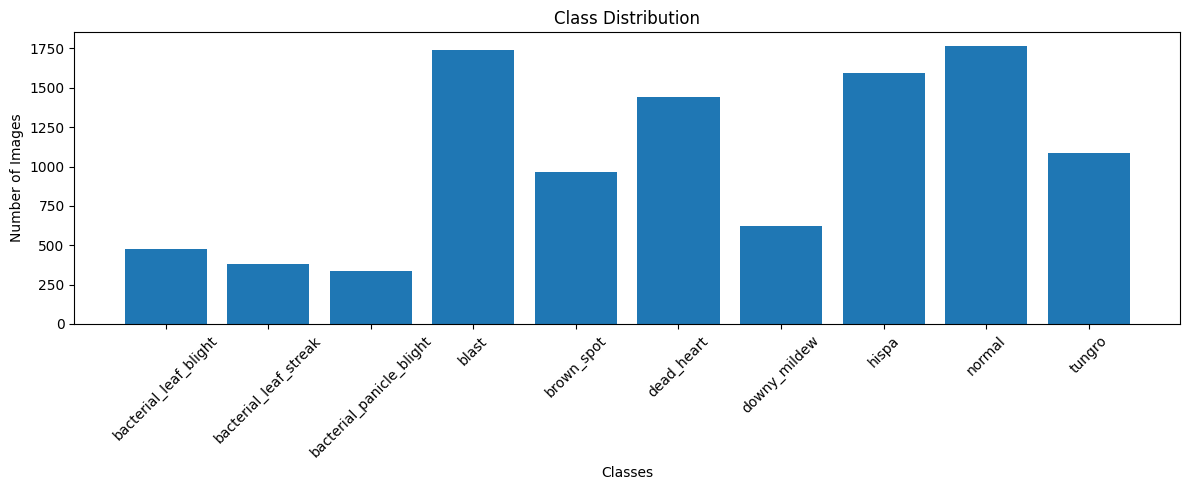

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.bar(class_counts.keys(), class_counts.values())
plt.xticks(rotation=45)
plt.title("Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.show()

In [ ]:
from PIL import Image
import random

# Pick 5 random classes
sample_classes = random.sample(classes, 5)

for cls in sample_classes:
    class_folder = os.path.join(train_path, cls)
    img_name = random.choice(os.listdir(class_folder))
    img_path = os.path.join(class_folder, img_name)

    try:
        img = Image.open(img_path)
        print(f"{cls} → {img.size}, Mode: {img.mode}")
    except:
        print(f"Error loading {img_path}")

bacterial_leaf_streak → (480, 640), Mode: RGB
bacterial_leaf_blight → (480, 640), Mode: RGB
brown_spot → (480, 640), Mode: RGB
tungro → (480, 640), Mode: RGB
downy_mildew → (480, 640), Mode: RGB


In [ ]:
from sklearn.model_selection import StratifiedKFold

image_paths = []
labels = []

class_to_idx = {cls: idx for idx, cls in enumerate(classes)}

for cls in classes:
    class_folder = os.path.join(train_path, cls)
    for img_name in os.listdir(class_folder):
        image_paths.append(os.path.join(class_folder, img_name))
        labels.append(class_to_idx[cls])

print("Total images collected:", len(image_paths))

Total images collected: 10407


In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

folds = []

for fold, (train_idx, val_idx) in enumerate(skf.split(image_paths, labels)):
    print(f"\nFold {fold}")
    print("Train size:", len(train_idx))
    print("Validation size:", len(val_idx))
    folds.append((train_idx, val_idx))


Fold 0
Train size: 8325
Validation size: 2082

Fold 1
Train size: 8325
Validation size: 2082

Fold 2
Train size: 8326
Validation size: 2081

Fold 3
Train size: 8326
Validation size: 2081

Fold 4
Train size: 8326
Validation size: 2081


In [ ]:
import numpy as np

for fold, (train_idx, val_idx) in enumerate(folds):
    val_labels = np.array(labels)[val_idx]
    unique, counts = np.unique(val_labels, return_counts=True)

    print(f"\nFold {fold} validation distribution:")
    for u, c in zip(unique, counts):
        print(f"Class {u}: {c}")


Fold 0 validation distribution:
Class 0: 96
Class 1: 76
Class 2: 68
Class 3: 347
Class 4: 193
Class 5: 289
Class 6: 124
Class 7: 318
Class 8: 353
Class 9: 218

Fold 1 validation distribution:
Class 0: 96
Class 1: 76
Class 2: 67
Class 3: 348
Class 4: 193
Class 5: 288
Class 6: 124
Class 7: 319
Class 8: 353
Class 9: 218

Fold 2 validation distribution:
Class 0: 96
Class 1: 76
Class 2: 67
Class 3: 348
Class 4: 193
Class 5: 288
Class 6: 124
Class 7: 319
Class 8: 353
Class 9: 217

Fold 3 validation distribution:
Class 0: 96
Class 1: 76
Class 2: 67
Class 3: 348
Class 4: 193
Class 5: 288
Class 6: 124
Class 7: 319
Class 8: 353
Class 9: 217

Fold 4 validation distribution:
Class 0: 95
Class 1: 76
Class 2: 68
Class 3: 347
Class 4: 193
Class 5: 289
Class 6: 124
Class 7: 319
Class 8: 352
Class 9: 218


from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

In [ ]:
from torch.utils.data import Dataset
from PIL import Image

class PaddyDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert("RGB")
        label = self.labels[idx]

        if self.transform:
            img = self.transform(img)

        return img, label

In [ ]:
print("train_transform exists?", 'train_transform' in globals())
print("val_transform exists?", 'val_transform' in globals())

train_transform exists? False
val_transform exists? False


In [ ]:
import torchvision.transforms as transforms

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Transforms ready ✅")

Transforms ready ✅


In [ ]:
from torch.utils.data import DataLoader
import numpy as np

fold = 0
train_idx, val_idx = folds[fold]

train_paths = np.array(image_paths)[train_idx]
train_labels = np.array(labels)[train_idx]

val_paths = np.array(image_paths)[val_idx]
val_labels = np.array(labels)[val_idx]

train_dataset = PaddyDataset(train_paths, train_labels, transform=train_transform)
val_dataset = PaddyDataset(val_paths, val_labels, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))

Train batches: 261
Val batches: 66


In [ ]:
all_folds_data = []

for fold, (train_idx, val_idx) in enumerate(folds):

    train_paths = np.array(image_paths)[train_idx]
    train_labels = np.array(labels)[train_idx]

    val_paths = np.array(image_paths)[val_idx]
    val_labels = np.array(labels)[val_idx]

    train_dataset = PaddyDataset(train_paths, train_labels, transform=train_transform)
    val_dataset = PaddyDataset(val_paths, val_labels, transform=val_transform)

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

    all_folds_data.append({
        "fold": fold,
        "train_loader": train_loader,
        "val_loader": val_loader
    })

    print(f"Fold {fold} ready: Train {len(train_loader)} batches | Val {len(val_loader)} batches")

Fold 0 ready: Train 261 batches | Val 66 batches
Fold 1 ready: Train 261 batches | Val 66 batches
Fold 2 ready: Train 261 batches | Val 66 batches
Fold 3 ready: Train 261 batches | Val 66 batches
Fold 4 ready: Train 261 batches | Val 66 batches


In [ ]:
import pickle

fold_indices_path = "/content/drive/MyDrive/paddy_project/fold_indices.pkl"

with open(fold_indices_path, "wb") as f:
    pickle.dump(folds, f)

print("Fold indices saved successfully.")

Fold indices saved successfully.


In [ ]:
class_mapping_path = "/content/drive/MyDrive/paddy_project/class_to_idx.pkl"

with open(class_mapping_path, "wb") as f:
    pickle.dump(class_to_idx, f)

print("Class mapping saved.")

Class mapping saved.


In [ ]:
images, labels_batch = next(iter(train_loader))

print("Batch image shape:", images.shape)
print("Batch label shape:", labels_batch.shape)

Batch image shape: torch.Size([32, 3, 224, 224])
Batch label shape: torch.Size([32])


In [ ]:
import torch
torch.cuda.is_available()

True

In [ ]:
!pip install timm

In [ ]:
import torch
import timm
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [ ]:
base_path = "/content/drive/MyDrive/paddy_project"

folders = ["models", "logs", "predictions"]

for folder in folders:
    os.makedirs(os.path.join(base_path, folder), exist_ok=True)

print("Project structure ready ✅")

Project structure ready ✅


In [ ]:
import timm
import torch.nn as nn

model = timm.create_model(
    'efficientnet_b0',
    pretrained=True,
    num_classes=len(class_to_idx)
)

model = model.to(device)

print("Model loaded successfully 🚀")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

Model loaded successfully 🚀


In [ ]:
# Loss Function
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)

print("Loss and Optimizer ready ✅")

Loss and Optimizer ready ✅


In [ ]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        # Accuracy calculation
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(dataloader)
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

print("Training function ready ✅")

Training function ready ✅


In [ ]:
def validate_one_epoch(model, dataloader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(dataloader)
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

print("Validation function ready ✅")

Validation function ready ✅


In [ ]:
# Define optimizer (if not already defined)
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=3e-4,
    weight_decay=1e-4
)

num_epochs = 5  # short test run

# Use Fold 0
fold_data = all_folds_data[0]
train_loader = fold_data["train_loader"]
val_loader = fold_data["val_loader"]

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )

    val_loss, val_acc = validate_one_epoch(
        model, val_loader, criterion, device
    )

    print(f"\nEpoch [{epoch+1}/{num_epochs}]")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")


Epoch [1/5]
Train Loss: 0.8609 | Train Acc: 0.7498
Val Loss:   0.3065 | Val Acc:   0.9025

Epoch [2/5]
Train Loss: 0.1957 | Train Acc: 0.9398
Val Loss:   0.2145 | Val Acc:   0.9395

Epoch [3/5]
Train Loss: 0.0981 | Train Acc: 0.9701
Val Loss:   0.2006 | Val Acc:   0.9462

Epoch [4/5]
Train Loss: 0.0946 | Train Acc: 0.9713
Val Loss:   0.2154 | Val Acc:   0.9457

Epoch [5/5]
Train Loss: 0.0751 | Train Acc: 0.9774
Val Loss:   0.1696 | Val Acc:   0.9558


Summary

Total images: 10,407

Total classes: 10

Stratified 5-fold cross validation implemented

Data augmentation applied

PyTorch Dataset and DataLoader prepared

Fold indices saved for reproducibility

In [ ]:
torch.save(
    model.state_dict(),
    "/content/drive/MyDrive/paddy_project/models/fold0_model.pth"
)

print("Fold 0 saved ✅")

Fold 0 saved ✅


In [ ]:
import timm
import torch
import torch.nn as nn

# Recreate fresh model
model = timm.create_model(
    "efficientnet_b0",
    pretrained=True,
    num_classes=10
)

model = model.to(device)

# Recreate optimizer
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=3e-4,
    weight_decay=1e-4
)

print("Fold 1 model initialized ✅")

Fold 1 model initialized ✅


In [ ]:
fold_data = all_folds_data[1]   # <-- Fold 1 now
train_loader = fold_data["train_loader"]
val_loader = fold_data["val_loader"]

print("Fold 1 data ready ✅")

Fold 1 data ready ✅


In [ ]:
num_epochs = 5

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )

    val_loss, val_acc = validate_one_epoch(
        model, val_loader, criterion, device
    )

    print(f"\nEpoch [{epoch+1}/{num_epochs}]")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")


Epoch [1/5]
Train Loss: 0.8643 | Train Acc: 0.7477
Val Loss:   0.3235 | Val Acc:   0.8982

Epoch [2/5]
Train Loss: 0.1939 | Train Acc: 0.9398
Val Loss:   0.2082 | Val Acc:   0.9419

Epoch [3/5]
Train Loss: 0.1049 | Train Acc: 0.9671
Val Loss:   0.1816 | Val Acc:   0.9529

Epoch [4/5]
Train Loss: 0.0809 | Train Acc: 0.9751
Val Loss:   0.1852 | Val Acc:   0.9529

Epoch [5/5]
Train Loss: 0.0781 | Train Acc: 0.9748
Val Loss:   0.1741 | Val Acc:   0.9577


In [ ]:
torch.save(
    model.state_dict(),
    "/content/drive/MyDrive/paddy_project/models/fold1_model.pth"
)

print("Fold 1 saved ✅")

Fold 1 saved ✅


In [ ]:
import timm
import torch
import torch.nn as nn

model = timm.create_model(
    "efficientnet_b0",
    pretrained=True,
    num_classes=10
)

model = model.to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=3e-4,
    weight_decay=1e-4
)

print("Fold 2 model initialized ✅")

Fold 2 model initialized ✅


In [ ]:
fold_data = all_folds_data[2]   # Fold 2
train_loader = fold_data["train_loader"]
val_loader = fold_data["val_loader"]

print("Fold 2 data ready ✅")

Fold 2 data ready ✅


In [ ]:
num_epochs = 5

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )

    val_loss, val_acc = validate_one_epoch(
        model, val_loader, criterion, device
    )

    print(f"\nFold 2 - Epoch [{epoch+1}/{num_epochs}]")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")


Fold 2 - Epoch [1/5]
Train Loss: 0.8934 | Train Acc: 0.7359
Val Loss:   0.3605 | Val Acc:   0.9034

Fold 2 - Epoch [2/5]
Train Loss: 0.2002 | Train Acc: 0.9396
Val Loss:   0.2198 | Val Acc:   0.9433

Fold 2 - Epoch [3/5]
Train Loss: 0.1018 | Train Acc: 0.9690
Val Loss:   0.1749 | Val Acc:   0.9524

Fold 2 - Epoch [4/5]
Train Loss: 0.0817 | Train Acc: 0.9741
Val Loss:   0.1864 | Val Acc:   0.9553

Fold 2 - Epoch [5/5]
Train Loss: 0.0760 | Train Acc: 0.9787
Val Loss:   0.2023 | Val Acc:   0.9500


In [ ]:
torch.save(
    model.state_dict(),
    "/content/drive/MyDrive/paddy_project/models/fold2_model.pth"
)

print("Fold 2 saved ✅")

Fold 2 saved ✅


In [ ]:
model = timm.create_model(
    "efficientnet_b0",
    pretrained=True,
    num_classes=10
)

model = model.to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=3e-4,
    weight_decay=1e-4
)

print("Fold 3 model initialized ✅")

Fold 3 model initialized ✅


In [ ]:
fold_data = all_folds_data[3]   # Fold 3
train_loader = fold_data["train_loader"]
val_loader = fold_data["val_loader"]

print("Fold 3 data ready ✅")

Fold 3 data ready ✅


In [ ]:
num_epochs = 5

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )

    val_loss, val_acc = validate_one_epoch(
        model, val_loader, criterion, device
    )

    print(f"\nFold 3 - Epoch [{epoch+1}/{num_epochs}]")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")


Fold 3 - Epoch [1/5]
Train Loss: 0.8449 | Train Acc: 0.7497
Val Loss:   0.3233 | Val Acc:   0.9082

Fold 3 - Epoch [2/5]
Train Loss: 0.1922 | Train Acc: 0.9423
Val Loss:   0.1865 | Val Acc:   0.9462

Fold 3 - Epoch [3/5]
Train Loss: 0.1147 | Train Acc: 0.9653
Val Loss:   0.1943 | Val Acc:   0.9558

Fold 3 - Epoch [4/5]
Train Loss: 0.0813 | Train Acc: 0.9757
Val Loss:   0.1741 | Val Acc:   0.9582

Fold 3 - Epoch [5/5]
Train Loss: 0.0732 | Train Acc: 0.9769
Val Loss:   0.1909 | Val Acc:   0.9524


In [ ]:
torch.save(
    model.state_dict(),
    "/content/drive/MyDrive/paddy_project/models/fold3_model.pth"
)

print("Fold 3 saved ✅")

Fold 3 saved ✅


In [ ]:
model = timm.create_model(
    "efficientnet_b0",
    pretrained=True,
    num_classes=10
)

model = model.to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=3e-4,
    weight_decay=1e-4
)

print("Fold 4 model initialized ✅")

Fold 4 model initialized ✅


In [ ]:
fold_data = all_folds_data[4]   # Fold 4
train_loader = fold_data["train_loader"]
val_loader = fold_data["val_loader"]

print("Fold 4 data ready ✅")

Fold 4 data ready ✅


In [ ]:
num_epochs = 5

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )

    val_loss, val_acc = validate_one_epoch(
        model, val_loader, criterion, device
    )

    print(f"\nFold 4 - Epoch [{epoch+1}/{num_epochs}]")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")


Fold 4 - Epoch [1/5]
Train Loss: 0.8965 | Train Acc: 0.7323
Val Loss:   0.3139 | Val Acc:   0.9111

Fold 4 - Epoch [2/5]
Train Loss: 0.2007 | Train Acc: 0.9410
Val Loss:   0.1900 | Val Acc:   0.9423

Fold 4 - Epoch [3/5]
Train Loss: 0.1115 | Train Acc: 0.9663
Val Loss:   0.1771 | Val Acc:   0.9543

Fold 4 - Epoch [4/5]
Train Loss: 0.0802 | Train Acc: 0.9757
Val Loss:   0.1855 | Val Acc:   0.9529

Fold 4 - Epoch [5/5]
Train Loss: 0.0719 | Train Acc: 0.9761
Val Loss:   0.1789 | Val Acc:   0.9510


In [ ]:
torch.save(
    model.state_dict(),
    "/content/drive/MyDrive/paddy_project/models/fold4_model.pth"
)

print("Fold 4 saved ✅")

Fold 4 saved ✅


In [ ]:
fold_accuracies = [0.9558, 0.9577, 0.9500, 0.9524, 0.9510]

avg_cv_acc = sum(fold_accuracies) / len(fold_accuracies)

print("Average Cross-Validation Accuracy:", round(avg_cv_acc, 4))

Average Cross-Validation Accuracy: 0.9534


In [ ]:
# Create full dataset
full_dataset = PaddyDataset(
    image_paths,
    labels,
    transform=train_transform
)

full_loader = DataLoader(
    full_dataset,
    batch_size=32,
    shuffle=True
)

print("Full dataset ready ✅")

Full dataset ready ✅


In [ ]:
model = timm.create_model(
    "efficientnet_b0",
    pretrained=True,
    num_classes=10
)

model = model.to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=3e-4,
    weight_decay=1e-4
)

print("Final model initialized ✅")

Final model initialized ✅


In [ ]:
num_epochs = 5  # or 8 if you want stronger final model

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(
        model, full_loader, criterion, optimizer, device
    )

    print(f"\nFinal Model - Epoch [{epoch+1}/{num_epochs}]")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")


Final Model - Epoch [1/5]
Train Loss: 0.7834 | Train Acc: 0.7707

Final Model - Epoch [2/5]
Train Loss: 0.1802 | Train Acc: 0.9447

Final Model - Epoch [3/5]
Train Loss: 0.0975 | Train Acc: 0.9710

Final Model - Epoch [4/5]
Train Loss: 0.0663 | Train Acc: 0.9797

Final Model - Epoch [5/5]
Train Loss: 0.0765 | Train Acc: 0.9802


In [ ]:
torch.save(
    model.state_dict(),
    "/content/drive/MyDrive/paddy_project/models/final_model.pth"
)

print("Final model saved ✅")

Final model saved ✅


In [ ]:
# Load Fold 0 model for evaluation
model = timm.create_model("efficientnet_b0", pretrained=False, num_classes=10)
model.load_state_dict(torch.load("/content/drive/MyDrive/paddy_project/models/fold0_model.pth"))
model = model.to(device)
model.eval()

print("Fold 0 model loaded for evaluation ✅")

Fold 0 model loaded for evaluation ✅


In [ ]:
fold_data = all_folds_data[0]
val_loader = fold_data["val_loader"]

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print("Predictions collected ✅")

Predictions collected ✅


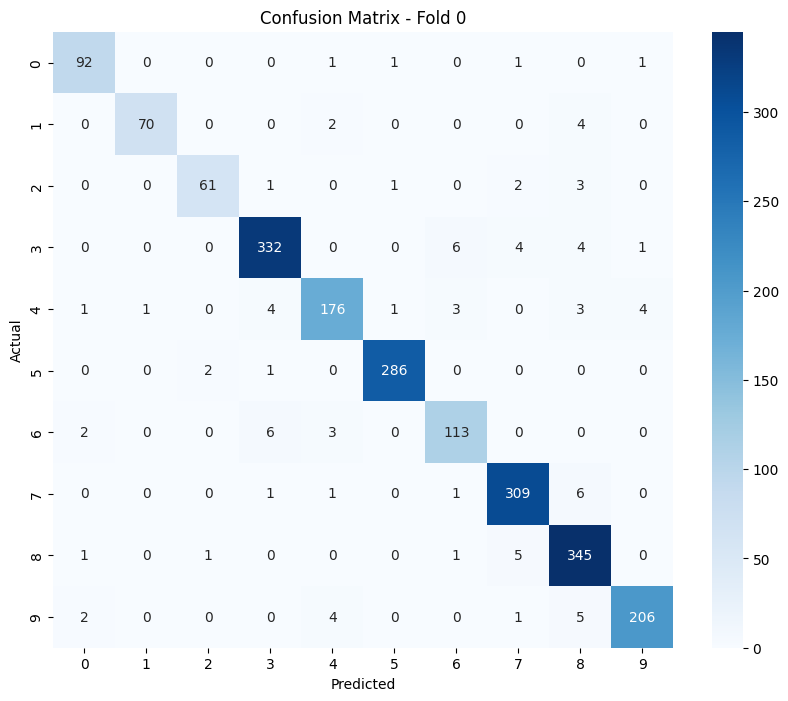

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Fold 0")
plt.show()

In [ ]:
print(classification_report(all_labels, all_preds, target_names=classes))

                          precision    recall  f1-score   support

   bacterial_leaf_blight       0.94      0.96      0.95        96
   bacterial_leaf_streak       0.99      0.92      0.95        76
bacterial_panicle_blight       0.95      0.90      0.92        68
                   blast       0.96      0.96      0.96       347
              brown_spot       0.94      0.91      0.93       193
              dead_heart       0.99      0.99      0.99       289
            downy_mildew       0.91      0.91      0.91       124
                   hispa       0.96      0.97      0.97       318
                  normal       0.93      0.98      0.95       353
                  tungro       0.97      0.94      0.96       218

                accuracy                           0.96      2082
               macro avg       0.95      0.94      0.95      2082
            weighted avg       0.96      0.96      0.96      2082

